# Market (S&P 500 daily closes): the edge that was too easy

*Notebook journey for section 3. Every number the chapter uses is produced here, and every data figure is drawn here from the real prices. We read one column of prices, turn it into a task, then meet the first trap: a split that leaks the future.*

## a. Reading the problem

all we have: 6664 daily closing prices, a single column in date order
first six closes: [1455.22, 1399.42, 1402.11, 1403.45, 1441.47, 1457.6]
the price wanders from 677 to 7610 over the years

trace, one day at a time:
  day 1: close 1399.42  ->  moved -3.83%  ->  size 3.83%
  day 2: close 1402.11  ->  moved +0.19%  ->  size 0.19%
  day 3: close 1403.45  ->  moved +0.10%  ->  size 0.10%
  day 4: close 1441.47  ->  moved +2.71%  ->  size 2.71%
  day 5: close 1457.60  ->  moved +1.12%  ->  size 1.12%

'usual' move size (the middle day): 0.54%   -> the busy / calm line
one row X[0] = the five sizes: ['3.83%', '0.19%', '0.10%', '2.71%', '1.12%']
        its answer = is tomorrow busier than usual? -> busy

rows: 6658   busy share: 0.500  (so a blind guess scores 0.5, a coin)


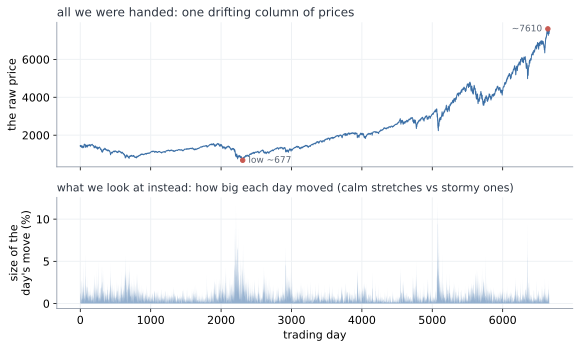

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np, os
import matplotlib.pyplot as plt

# --- house style (kept identical across every chapter's figures) ---
ACCENT, MUTED, RED, GRID = "#3a6ea5", "#b8c0cc", "#c85a52", "#eef1f4"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.edgecolor": "#8a94a3", "axes.linewidth": 0.8})
def clean(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)

FIG  = "figures" if os.path.isdir("figures") else "../figures"
DATA = "data/gspc_2026-07-03.csv" if os.path.exists("data/gspc_2026-07-03.csv") else "../data/gspc_2026-07-03.csv"

# --- all we were handed: ONE column of daily closing prices, in date order ---
close = np.loadtxt(DATA, skiprows=1)
print("all we have:", len(close), "daily closing prices, a single column in date order")
print("first six closes:", [round(float(v), 2) for v in close[:6]])
print("the price wanders from", round(float(close.min())), "to", round(float(close.max())), "over the years")

# --- turn each raw price into how much it MOVED, then the SIZE of that move ---
r = np.diff(close) / close[:-1]     # the daily move, as a fraction (a percent)
s = np.abs(r)                       # the SIZE of the move, forgetting up or down
print("\ntrace, one day at a time:")
for t in range(1, 6):
    print(f"  day {t}: close {close[t]:.2f}  ->  moved {r[t-1]*100:+.2f}%  ->  size {s[t-1]*100:.2f}%")

# --- the task: from the last five sizes, is TOMORROW a busy day (bigger than usual)? ---
L = 5
X = np.column_stack([s[i:len(s) - L + i] for i in range(L)])
fut = s[L:]; X = X[:len(fut)]
usual = float(np.median(s))                 # "usual" = the middle day; half above, half below
y = (fut > usual).astype(int)
print(f"\n'usual' move size (the middle day): {usual*100:.2f}%   -> the busy / calm line")
print("one row X[0] = the five sizes:", [f"{v*100:.2f}%" for v in X[0]])
print("        its answer = is tomorrow busier than usual? ->", "busy" if y[0] else "calm")
print(f"\nrows: {len(y)}   busy share: {y.mean():.3f}  (so a blind guess scores 0.5, a coin)")

# ---------------- FIGURE: all we have (price) -> what we look at (size) ----------------
fig, (axp, axs) = plt.subplots(2, 1, figsize=(8.2, 5.0), sharex=True,
                               gridspec_kw={"height_ratios": [1.3, 1.0]})
day = np.arange(len(close))
axp.plot(day, close, color=ACCENT, linewidth=1.0)
axp.scatter([int(close.argmin()), int(close.argmax())], [close.min(), close.max()],
            color=RED, s=20, zorder=5)
axp.text(int(close.argmin()), close.min(), f"  low ~{round(float(close.min()))}",
         va="center", ha="left", fontsize=9, color="#5a6472")
axp.text(int(close.argmax()), close.max(), f"~{round(float(close.max()))}  ",
         va="center", ha="right", fontsize=9, color="#5a6472")
axp.set_ylabel("the raw price"); clean(axp)
axp.set_title("all we were handed: one drifting column of prices",
              loc="left", fontsize=12, color="#2b333f")
axs.fill_between(day[1:], s * 100, color=ACCENT, alpha=0.55, linewidth=0)
axs.set_ylabel("size of the\nday's move (%)"); axs.set_xlabel("trading day"); clean(axs)
axs.set_title("what we look at instead: how big each day moved (calm stretches vs stormy ones)",
              loc="left", fontsize=11, color="#2b333f")
fig.tight_layout()
fig.savefig(f"{FIG}/market_data.svg", bbox_inches="tight"); plt.show()


## b. The edge that was too easy

We run it exactly by the book: the standard random hold-out (a shuffle), the same small network, the honest sealed test. Then, like the careful practitioner Loan taught us to be, we do not stop at the first good number. We measure the way real life measures, past to future, and watch whether the two agree. Direction serves as a control at the end: on a task we already know is a coin, a leak has nothing to inflate.

In [2]:
# ---- the same small network from Section 1 ----
def init(d, width, K, rng):
    return [rng.standard_normal((d, width))*0.1, np.zeros(width),
            rng.standard_normal((width, K))*0.1, np.zeros(K)]
def forward(Xb, p):
    W1, b1, W2, b2 = p; a = Xb@W1+b1; h = np.maximum(a, 0.0); z = h@W2+b2; return a, h, z
def softmax(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e/e.sum(1, keepdims=True)
def accuracy(p, Xb, yb): return float((forward(Xb, p)[2].argmax(1) == yb).mean())
def train(Xtr, ytr, width, lr, epochs, K, rng):
    p = init(Xtr.shape[1], width, K, rng); n = len(ytr); Y = np.zeros((n, K)); Y[np.arange(n), ytr] = 1.0
    for _ in range(epochs):
        a, h, z = forward(Xtr, p); dz = (softmax(z)-Y)/n; W1, b1, W2, b2 = p
        dW2 = h.T@dz; db2 = dz.sum(0); da = (dz@W2.T)*(a > 0); dW1 = Xtr.T@da; db1 = da.sum(0)
        p = [W1-lr*dW1, b1-lr*db1, W2-lr*dW2, b2-lr*db2]
    return p
def standardize(Xtr, Xte):
    m, sd = Xtr.mean(0), Xtr.std(0)+1e-9; return (Xtr-m)/sd, (Xte-m)/sd

def make(target, L=5):
    ret = np.diff(close)/close[:-1]; sz = np.abs(ret)
    feats = sz if target == "volatility" else ret
    Xf = np.column_stack([feats[i:len(feats)-L+i] for i in range(L)])
    if target == "volatility":
        fut = sz[L:]; Xf = Xf[:len(fut)]; yf = (fut > np.median(sz)).astype(int)
    else:
        fut = ret[L:]; Xf = Xf[:len(fut)]; yf = (fut > 0).astype(int)
    return Xf, yf

def split_idx(n, how, seed):
    ntest = n//5; nval = n//5                      # 20% test, 20% val (UNUSED), 60% train
    if how == "chronological":
        test = np.arange(n-ntest, n); train = np.arange(0, n-ntest-nval)      # first 60% -> last 20%
    else:
        idx = np.random.default_rng(1000+seed).permutation(n)
        test = idx[:ntest]; train = idx[ntest+nval:]                          # random 60% -> random 20%
    return train, test

def score(Xf, yf, how, seed, lr=0.3):
    tr, te = split_idx(len(yf), how, seed)
    Xtr, Xte = standardize(Xf[tr], Xf[te])
    p = train(Xtr, yf[tr], 16, lr, 300, 2, np.random.default_rng(seed))
    return accuracy(p, Xte, yf[te])

def walk_forward(Xf, yf, folds=5, lr=0.3):
    n = len(yf); bs = n//(folds+1); out = []
    for k in range(1, folds+1):
        tr = np.arange(0, k*bs); te = np.arange(k*bs, (k+1)*bs)
        Xtr, Xte = standardize(Xf[tr], Xf[te])
        p = train(Xtr, yf[tr], 16, lr, 300, 2, np.random.default_rng(k))
        out.append(accuracy(p, Xte, yf[te]))
    return float(np.mean(out)), out

Xv, yv = make("volatility"); Xd, yd = make("direction")
seeds = range(5)
v_sh = [score(Xv, yv, "shuffle", s) for s in seeds]
v_ch = [score(Xv, yv, "chronological", s) for s in seeds]
d_sh = [score(Xd, yd, "shuffle", s) for s in seeds]
d_ch = [score(Xd, yd, "chronological", s) for s in seeds]
v_wf, v_wf_folds = walk_forward(Xv, yv)
V_SH, V_CH, D_SH, D_CH = np.mean(v_sh), np.mean(v_ch), np.mean(d_sh), np.mean(d_ch)

print("VOLATILITY (busy tomorrow?):")
print(f"  shuffle (by the book) : {V_SH:.3f}   every shuffle {[round(x,3) for x in v_sh]}")
print(f"  chronological (honest): {V_CH:.3f}   {[round(x,3) for x in v_ch]}")
print(f"  walk-forward (rolling): {v_wf:.3f}")
print(f"  gap shuffle - chrono  : {V_SH-V_CH:+.3f}   (leak inflation, in all 5 seeds: {all(a>b for a,b in zip(v_sh,v_ch))})")
print("\nDIRECTION (up/down?) - CONTROL, a known coin:")
print(f"  shuffle {D_SH:.3f}   chronological {D_CH:.3f}   gap {D_SH-D_CH:+.3f}  (~0: nothing to leak)")
print("\nNEAR-TWINS (why shuffle leaks): consecutive rows overlap")
print(f"  X[0]: {[round(float(v),4) for v in Xv[0]]}")
print(f"  X[1]: {[round(float(v),4) for v in Xv[1]]}   (shares 4 of 5, shifted by one)")


VOLATILITY (busy tomorrow?):
  shuffle (by the book) : 0.612   every shuffle [0.607, 0.624, 0.621, 0.618, 0.59]
  chronological (honest): 0.587   [0.587, 0.586, 0.585, 0.588, 0.589]
  walk-forward (rolling): 0.601
  gap shuffle - chrono  : +0.025   (leak inflation, in all 5 seeds: True)

DIRECTION (up/down?) - CONTROL, a known coin:
  shuffle 0.540   chronological 0.539   gap +0.001  (~0: nothing to leak)

NEAR-TWINS (why shuffle leaks): consecutive rows overlap
  X[0]: [0.0383, 0.0019, 0.001, 0.0271, 0.0112]
  X[1]: [0.0019, 0.001, 0.0271, 0.0112, 0.0131]   (shares 4 of 5, shifted by one)


training accuracy (mean of 5 seeds): 0.494 untrained  ->  0.630 settled

is it doing something real, or just parroting one class?
  on the sealed test it answers BUSY 0.452 of the time, CALM 0.548
  it gets 0.564 of the busy days right, and 0.659 of the calm days right


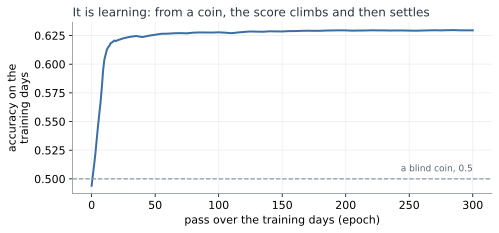

In [3]:
# ---- did it actually LEARN, and is it doing something real (not guessing one class)? ----
# averaged over the same five seeds, so no single lucky starting point can flatter the picture
def learning_curves(Xf, yf, seeds=range(5), how="shuffle", lr=0.3, epochs=300, width=16, every=5):
    marks = [0] + [e for e in range(1, epochs+1) if e <= 20 or e % every == 0]
    mset = set(marks); runs, bshare, bhit, chit = [], [], [], []
    for s in seeds:
        tr, te = split_idx(len(yf), how, s)
        Xtr, Xte = standardize(Xf[tr], Xf[te]); ytr, yte = yf[tr], yf[te]
        p = init(Xtr.shape[1], width, 2, np.random.default_rng(s)); n = len(ytr)
        Y = np.zeros((n, 2)); Y[np.arange(n), ytr] = 1.0
        got = {0: accuracy(p, Xtr, ytr)}                    # epoch 0: untrained weights
        for e in range(1, epochs+1):
            a, h, z = forward(Xtr, p); dz = (softmax(z)-Y)/n
            W1, b1, W2, b2 = p
            dW2 = h.T@dz; db2 = dz.sum(0); da = (dz@W2.T)*(a > 0); dW1 = Xtr.T@da; db1 = da.sum(0)
            p = [W1-lr*dW1, b1-lr*db1, W2-lr*dW2, b2-lr*db2]
            if e in mset: got[e] = accuracy(p, Xtr, ytr)
        runs.append([got[m] for m in marks])
        pr = forward(Xte, p)[2].argmax(1)
        bshare.append(float(pr.mean()))
        bhit.append(float((pr[yte == 1] == 1).mean())); chit.append(float((pr[yte == 0] == 0).mean()))
    return marks, np.mean(runs, 0), np.mean(bshare), np.mean(bhit), np.mean(chit)

marks, curve, bshare, bhit, chit = learning_curves(Xv, yv)
print(f"training accuracy (mean of 5 seeds): {curve[0]:.3f} untrained  ->  {curve[-1]:.3f} settled")
print("\nis it doing something real, or just parroting one class?")
print(f"  on the sealed test it answers BUSY {bshare:.3f} of the time, CALM {1-bshare:.3f}")
print(f"  it gets {bhit:.3f} of the busy days right, and {chit:.3f} of the calm days right")

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.plot(marks, curve, color=ACCENT, linewidth=2.0)
ax.axhline(0.5, color="#8a94a3", lw=1.2, ls="--")
ax.text(marks[-1], 0.505, "a blind coin, 0.5", ha="right", va="bottom", fontsize=9, color="#5a6472")
ax.set_xlabel("pass over the training days (epoch)")
ax.set_ylabel("accuracy on the\ntraining days")
ax.set_title("It is learning: from a coin, the score climbs and then settles", loc="left", fontsize=12, color="#2b333f")
clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/market_learning.svg", bbox_inches="tight"); plt.show()


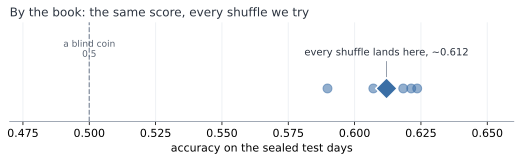

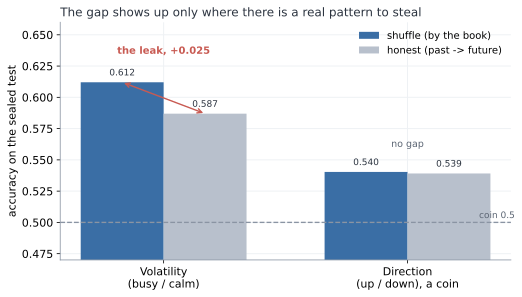

In [4]:
# ---------------- FIGURE: the score lands in the same place every shuffle ----------------
fig, ax = plt.subplots(figsize=(7.4, 2.4))
ax.axvline(0.5, color="#8a94a3", lw=1.3, ls="--")
ax.text(0.5, 1.9, "a blind coin\n0.5", color="#5a6472", fontsize=9, ha="center", va="bottom")
ax.scatter(v_sh, [1]*len(v_sh), s=80, color=ACCENT, alpha=0.55, zorder=4)
ax.scatter([V_SH], [1], s=230, color=ACCENT, edgecolor="white", linewidth=1.5, marker="D", zorder=6)
ax.annotate(f"every shuffle lands here, ~{V_SH:.3f}", xy=(V_SH, 1), xytext=(V_SH, 2.0),
            fontsize=10, color="#2b333f", ha="center",
            arrowprops=dict(arrowstyle="->", color="#8a94a3", lw=0.9))
ax.set_xlim(0.47, 0.66); ax.set_ylim(0, 3)
ax.set_yticks([]); ax.set_xlabel("accuracy on the sealed test days")
ax.set_title("By the book: the same score, every shuffle we try", loc="left", fontsize=12, color="#2b333f")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["left"].set_visible(False)
ax.grid(True, axis="x", color=GRID, linewidth=1); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(f"{FIG}/market_shuffle.svg", bbox_inches="tight"); plt.show()

# ---------------- FIGURE: the gap appears only where there is a real pattern ----------------
fig, ax = plt.subplots(figsize=(7.4, 4.3))
groups = ["Volatility\n(busy / calm)", "Direction\n(up / down), a coin"]
xg = np.arange(2); w = 0.34
ax.axhline(0.5, color="#8a94a3", lw=1.3, ls="--")
ax.text(1.44, 0.502, "coin 0.5", color="#5a6472", fontsize=9, va="bottom", ha="right")
b1 = ax.bar(xg - w/2, [V_SH, D_SH], w, color=ACCENT, label="shuffle (by the book)")
b2 = ax.bar(xg + w/2, [V_CH, D_CH], w, color=MUTED, label="honest (past -> future)")
for rects in (b1, b2):
    for rr in rects:
        ax.text(rr.get_x()+rr.get_width()/2, rr.get_height()+0.004, f"{rr.get_height():.3f}",
                ha="center", va="bottom", fontsize=9, color="#2b333f")
ax.annotate("", xy=(-w/2, V_SH), xytext=(w/2, V_CH),
            arrowprops=dict(arrowstyle="<->", color=RED, lw=1.4))
ax.text(0.0, 0.637, f"the leak, +{V_SH-V_CH:.3f}", color=RED, fontsize=10, ha="center", va="center", fontweight="bold")
ax.text(1.0, D_SH+0.020, "no gap", color="#5a6472", fontsize=9.5, ha="center")
ax.set_xticks(xg); ax.set_xticklabels(groups)
ax.set_ylim(0.47, 0.66); ax.set_ylabel("accuracy on the sealed test")
ax.set_title("The gap shows up only where there is a real pattern to steal", loc="left", fontsize=12, color="#2b333f")
ax.legend(loc="upper right", frameon=False, fontsize=10)
clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/market_leak.svg", bbox_inches="tight"); plt.show()


## d. The step we had not questioned

Armed with the rule from part c (never trust a step you have only checked one way), we go back through the recipe hunting for the next step we took on faith. We find scaling. Then, once that breaks, we turn the same suspicion on the one number we had decided to keep.

Same days, same task, same honest split. Only the unit and the scaler change:
  size in percent + frozen scaler : 0.587
  size in points  + frozen scaler : 0.509   <- a coin
  size in points  + rolling scaler: 0.528

the frozen scaler is two numbers taken once, on the training years, then used forever:
  percent: froze normal at mean 0.85% (spread 0.94); by the test years it had drifted to 0.75%  (x0.9)
          so the test days land at |z| mean 0.59, max 9.25 from the frozen normal
  points: froze normal at mean 10.57 pts (spread 10.61); by the test years it had drifted to 37.07 pts  (x3.5)
          so the test days land at |z| mean 2.73, max 43.71 from the frozen normal


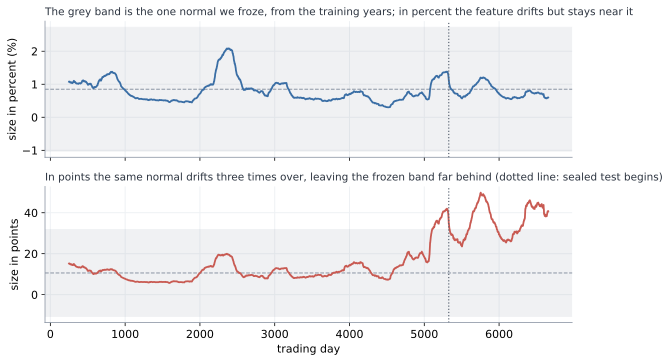

In [5]:
# ---- BOOM 1: same honest split, same task. Only the feature's UNIT and the scaler change ----
def load_scaled(kind):
    ret = np.diff(close)/close[:-1]
    pct = np.abs(ret)                                            # size in percent: stays in the same ballpark
    src = pct if kind == "percent" else np.abs(np.diff(close))   # size in points: drifts with the index level
    Xf = np.column_stack([src[i:len(src)-L+i] for i in range(L)])
    fut = pct[L:]; Xf = Xf[:len(fut)]
    yf = (fut > np.median(pct)).astype(int)                      # label ALWAYS from the percent size
    return Xf, yf

def chron_idx(nn):
    ntest = nn//5; nval = nn//5
    return np.arange(0, nn-ntest-nval), np.arange(nn-ntest, nn)  # first 60% train, last 20% test

def frozen(Xtr, Xte):
    m, sd = Xtr.mean(0), Xtr.std(0)+1e-9
    return (Xtr-m)/sd, (Xte-m)/sd

def rolling_z(Xf, W=250):                                        # each row scaled by its own trailing window
    Z = np.zeros_like(Xf)
    for j in range(Xf.shape[1]):
        c = Xf[:, j]
        cs = np.concatenate([[0.0], np.cumsum(c)]); cs2 = np.concatenate([[0.0], np.cumsum(c*c)])
        for t in range(len(c)):
            lo = max(0, t-W); mm = t-lo
            if mm < 30: continue
            mu = (cs[t]-cs[lo])/mm; var = (cs2[t]-cs2[lo])/mm - mu*mu
            Z[t, j] = (c[t]-mu)/(np.sqrt(max(var, 1e-18))+1e-9)
    return Z

def score_scaling(kind, scaler, seeds=range(5), lr=0.3):
    Xf, yf = load_scaled(kind); nn = len(yf); tr, te = chron_idx(nn)
    if scaler == "frozen":
        Xtr, Xte = frozen(Xf[tr], Xf[te])
    else:
        Z = rolling_z(Xf); Xtr, Xte = Z[tr], Z[te]
    a = [accuracy(train(Xtr, yf[tr], 16, lr, 300, 2, np.random.default_rng(s)), Xte, yf[te]) for s in seeds]
    return float(np.mean(a))

PCT_FROZ = score_scaling("percent", "frozen")
PTS_FROZ = score_scaling("points", "frozen")
PTS_ROLL = score_scaling("points", "rolling")
print("Same days, same task, same honest split. Only the unit and the scaler change:")
print(f"  size in percent + frozen scaler : {PCT_FROZ:.3f}")
print(f"  size in points  + frozen scaler : {PTS_FROZ:.3f}   <- a coin")
print(f"  size in points  + rolling scaler: {PTS_ROLL:.3f}")
print("\nthe frozen scaler is two numbers taken once, on the training years, then used forever:")
for kind in ("percent", "points"):
    Xf, yf = load_scaled(kind); tr, te = chron_idx(len(yf))
    col = Xf[:, -1].astype(float) * (100 if kind == "percent" else 1)   # most recent day's size in each row
    m_tr, s_tr = col[tr].mean(), col[tr].std()                          # the mean and std we froze
    m_te = col[te].mean()                                              # what a normal day actually became
    _, Xte = frozen(Xf[tr], Xf[te]); unit = "%" if kind == "percent" else " pts"
    print(f"  {kind}: froze normal at mean {m_tr:.2f}{unit} (spread {s_tr:.2f}); by the test years it had drifted to {m_te:.2f}{unit}  (x{m_te/m_tr:.1f})")
    print(f"          so the test days land at |z| mean {np.abs(Xte).mean():.2f}, max {np.abs(Xte).max():.2f} from the frozen normal")

# ---------------- FIGURE: what the scaler called normal, and where the feature actually went -------------
fig, axes = plt.subplots(2, 1, figsize=(8.2, 5.2), sharex=True)
W = 250; ker = np.ones(W)/W
for ax, kind, lab, colr in zip(axes, ("percent", "points"),
                               ("size in percent (%)", "size in points"), (ACCENT, RED)):
    Xf, yf = load_scaled(kind); tr, te = chron_idx(len(yf))
    col = Xf[:, -1].astype(float) * (100 if kind == "percent" else 1)
    mu, sd = col[tr].mean(), col[tr].std()
    ax.axhspan(mu-2*sd, mu+2*sd, color="#8a94a3", alpha=0.13)
    ax.axhline(mu, color="#8a94a3", lw=1.0, ls="--")
    ax.plot(np.arange(W-1, len(col)), np.convolve(col, ker, mode="valid"), color=colr, lw=1.8)
    ax.axvline(te[0], color="#5a6472", lw=1.2, ls=":")
    ax.set_ylabel(lab); clean(ax)
axes[0].set_title("The grey band is the one normal we froze, from the training years; in percent the feature drifts but stays near it",
                  loc="left", fontsize=10.5, color="#2b333f")
axes[1].set_title("In points the same normal drifts three times over, leaving the frozen band far behind (dotted line: sealed test begins)",
                  loc="left", fontsize=10.5, color="#2b333f")
axes[1].set_xlabel("trading day")
fig.tight_layout(); fig.savefig(f"{FIG}/market_drift.svg", bbox_inches="tight"); plt.show()


era 1: model 0.519   busy share 0.456   the bar that era sets 0.544   margin -0.025


era 2: model 0.602   busy share 0.541   the bar that era sets 0.541   margin +0.061


era 3: model 0.651   busy share 0.374   the bar that era sets 0.626   margin +0.026


era 4: model 0.654   busy share 0.472   the bar that era sets 0.528   margin +0.127


era 5: model 0.582   busy share 0.522   the bar that era sets 0.522   margin +0.060

across eras the score runs 0.519 to 0.654, a spread of 0.135
sampling noise on a 1109-day block is about 0.015, so the swing is 9.2x noise
margin over the bar each era actually sets: mean +0.050, from -0.025 to +0.127
the headline was 0.612 against a flat coin, which read as +0.112


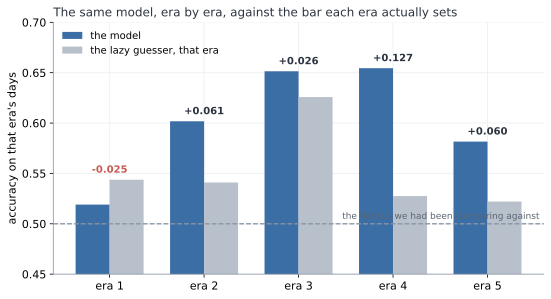

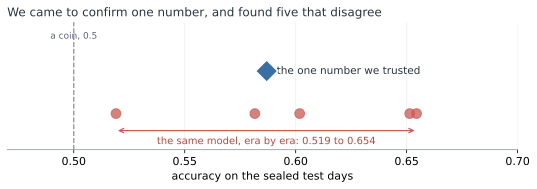

In [6]:
# ---- BOOM 2: the number we KEPT. Does it hold still, and what is the right bar in each era? ----
bs = len(yv)//6
eras = []
for k in range(1, 6):
    tr = np.arange(0, k*bs); te = np.arange(k*bs, (k+1)*bs)
    Xtr, Xte = standardize(Xv[tr], Xv[te])
    a = float(np.mean([accuracy(train(Xtr, yv[tr], 16, 0.3, 300, 2, np.random.default_rng(s)), Xte, yv[te])
                       for s in range(5)]))
    busy = float(yv[te].mean()); base = max(busy, 1-busy)
    eras.append((k, a, busy, base, a-base))
    print(f"era {k}: model {a:.3f}   busy share {busy:.3f}   the bar that era sets {base:.3f}   margin {a-base:+.3f}")

accs = [e[1] for e in eras]; marg = [e[4] for e in eras]
se = float(np.sqrt(0.6*0.4/bs))
print(f"\nacross eras the score runs {min(accs):.3f} to {max(accs):.3f}, a spread of {max(accs)-min(accs):.3f}")
print(f"sampling noise on a {bs}-day block is about {se:.3f}, so the swing is {(max(accs)-min(accs))/se:.1f}x noise")
print(f"margin over the bar each era actually sets: mean {np.mean(marg):+.3f}, from {min(marg):+.3f} to {max(marg):+.3f}")
print(f"the headline was 0.612 against a flat coin, which read as +{0.612-0.5:.3f}")

# ---------------- FIGURE: the model era by era, against the bar that era actually sets ----------------
fig, ax = plt.subplots(figsize=(7.8, 4.3))
xs = np.arange(1, 6); w = 0.36
ax.bar(xs-w/2, [e[1] for e in eras], w, color=ACCENT, label="the model")
ax.bar(xs+w/2, [e[3] for e in eras], w, color=MUTED, label="the lazy guesser, that era")
ax.axhline(0.5, color="#8a94a3", lw=1.3, ls="--")
ax.text(5.55, 0.503, "the flat 0.5 we had been comparing against", ha="right", va="bottom",
        fontsize=9, color="#5a6472")
for e in eras:
    ax.text(e[0], max(e[1], e[3])+0.007, f"{e[4]:+.3f}", ha="center", fontsize=10,
            color=(RED if e[4] < 0 else "#2b333f"), fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels([f"era {k}" for k in xs])
ax.set_ylim(0.45, 0.70); ax.set_ylabel("accuracy on that era's days")
ax.set_title("The same model, era by era, against the bar each era actually sets",
             loc="left", fontsize=12, color="#2b333f")
ax.legend(loc="upper left", frameon=False, fontsize=10); clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/market_eras.svg", bbox_inches="tight"); plt.show()

# ---------------- FIGURE: one number we trusted, versus the era-by-era scatter ----------------
fig, ax = plt.subplots(figsize=(7.6, 2.8))
ax.axvline(0.5, color="#8a94a3", lw=1.3, ls="--")
ax.text(0.5, 2.72, "a coin, 0.5", color="#5a6472", fontsize=9, ha="center", va="bottom")
ax.scatter([V_CH], [2], s=250, color=ACCENT, edgecolor="white", linewidth=1.5, marker="D", zorder=6)
ax.text(V_CH, 2.0, "   the one number we trusted", va="center", ha="left", fontsize=10.5, color="#2b333f")
ax.scatter(accs, [1]*len(accs), s=95, color=RED, alpha=0.75, zorder=5)
ax.annotate("", xy=(min(accs), 0.60), xytext=(max(accs), 0.60),
            arrowprops=dict(arrowstyle="<->", color="#c85a52", lw=1.2))
ax.text((min(accs)+max(accs))/2, 0.46, f"the same model, era by era: {min(accs):.3f} to {max(accs):.3f}",
        ha="center", va="top", fontsize=10, color="#b04a42")
ax.set_xlim(0.47, 0.70); ax.set_ylim(0.15, 3.15)
ax.set_yticks([]); ax.set_xlabel("accuracy on the sealed test days")
ax.set_title("We came to confirm one number, and found five that disagree", loc="left", fontsize=12, color="#2b333f")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.spines["left"].set_visible(False)
ax.grid(True, axis="x", color=GRID, linewidth=1); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig(f"{FIG}/market_spread.svg", bbox_inches="tight"); plt.show()
